# Part 1: Selecting and analyzing the dataset

I have chosen a simple dataset, which you can find in the following [link](https://archive.ics.uci.edu/dataset/186/wine+quality)
This dataset has variables about the wine and its quality
it has a total of 11 features, where one of them is the quality, which is measured from 1 to 10, where 1 is bad and 10 really good

In [3]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import  mean_squared_error, mean_absolute_error

import os

from NeuralNet import NeuralNet
from helpers import denormalize, save_prediction_to_csv, get_prediction, show_prediction_vs_real_values, create_csv

results_df = create_csv()
metrics = {}

## Checking NN with other dataset that can be model with a regression

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sureshgupta/health-insurance-data-set")

print("Path to dataset files:", path)

/Users/hjaviersarmientoy/Documents/1_projects/complete_master_in_cybersecurity_and_ia/NEC_neural_and_evolutionary_computation/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/hjaviersarmientoy/.cache/kagglehub/datasets/sureshgupta/health-insurance-data-set/versions/1


In [5]:
full_file_path = '/Users/hjaviersarmientoy/.cache/kagglehub/datasets/sureshgupta/health-insurance-data-set/versions/1/1651277648862_healthinsurance.csv'
df = pd.read_csv(full_file_path)

# Display the first few rows to confirm the import was successful
print(df.head())


    age     sex  weight   bmi hereditary_diseases  no_of_dependents  smoker  \
0  60.0    male      64  24.3           NoDisease                 1       0   
1  49.0  female      75  22.6           NoDisease                 1       0   
2  32.0  female      64  17.8            Epilepsy                 2       1   
3  61.0  female      53  36.4           NoDisease                 1       1   
4  19.0  female      50  20.6           NoDisease                 0       0   

          city  bloodpressure  diabetes  regular_ex    job_title    claim  
0      NewYork             72         0           0        Actor  13112.6  
1       Boston             78         1           1     Engineer   9567.0  
2  Phildelphia             88         1           1  Academician  32734.2  
3    Pittsburg             72         1           0         Chef  48517.6  
4      Buffalo             82         1           0   HomeMakers   1731.7  


In [6]:
df.shape

(15000, 13)

## Pre-processing data

In [7]:
df.isnull().sum()

age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

In [8]:
from sklearn.impute import SimpleImputer

# Initialize the SimpleImputer with the strategy 'mean'
imputer = SimpleImputer(strategy='mean')

# Specify the columns with missing values that we want to impute
columns_with_missing_values = ['age', 'bmi']

# Apply the imputer to fill missing values with the mean
df[columns_with_missing_values] = imputer.fit_transform(df[columns_with_missing_values])

df.isnull().sum()

age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
claim                  0
dtype: int64

In [9]:
df.describe(include='all')

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
count,15000.000000,15000,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000,15000.000000
unique,NaN,2,NaN,NaN,10,NaN,NaN,91,NaN,NaN,NaN,35,NaN
top,NaN,female,NaN,NaN,NoDisease,NaN,NaN,NewOrleans,NaN,NaN,NaN,Student,NaN
freq,NaN,7652,NaN,NaN,13998,NaN,NaN,302,NaN,NaN,NaN,1320,NaN
mean,39.547521,NaN,64.909600,30.266413,NaN,1.129733,0.198133,NaN,68.650133,0.777000,0.224133,NaN,13401.437620
std,13.829705,NaN,13.701935,5.924606,NaN,1.228469,0.398606,NaN,19.418515,0.416272,0.417024,NaN,12148.239619
min,18.000000,NaN,34.000000,16.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,1121.900000
25%,27.000000,NaN,54.000000,25.900000,NaN,0.000000,0.000000,NaN,64.000000,1.000000,0.000000,NaN,4846.900000
50%,40.000000,NaN,63.000000,29.800000,NaN,1.000000,0.000000,NaN,71.000000,1.000000,0.000000,NaN,9545.650000
75%,51.000000,NaN,76.000000,34.100000,NaN,2.000000,0.000000,NaN,80.000000,1.000000,0.000000,NaN,16519.125000


In [10]:
df["sex"].unique()

array(['male', 'female'], dtype=object)

In [11]:
#values mapped to integers (0 and 1)
df['sex']=df['sex'].map({'female':0,'male':1})
df["sex"].unique()

array([1, 0])

In [12]:
df["hereditary_diseases"].unique()

array(['NoDisease', 'Epilepsy', 'EyeDisease', 'Alzheimer', 'Arthritis',
       'HeartDisease', 'Diabetes', 'Cancer', 'High BP', 'Obesity'],
      dtype=object)

In [13]:
df["hereditary_diseases"]=df["hereditary_diseases"].map({'NoDisease':0, 'Epilepsy':1, 'EyeDisease':2, 'Alzheimer':3, 'Arthritis':4,
       'HeartDisease':5, 'Diabetes':6, 'Cancer':7, 'High BP':8, 'Obesity':9})
df["hereditary_diseases"].unique()
# mapping done

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [14]:
df["city"].unique()

array(['NewYork', 'Boston', 'Phildelphia', 'Pittsburg', 'Buffalo',
       'AtlanticCity', 'Portland', 'Cambridge', 'Hartford', 'Springfield',
       'Syracuse', 'Baltimore', 'York', 'Trenton', 'Warwick',
       'WashingtonDC', 'Providence', 'Harrisburg', 'Newport', 'Stamford',
       'Worcester', 'Atlanta', 'Brimingham', 'Charleston', 'Charlotte',
       'Louisville', 'Memphis', 'Nashville', 'NewOrleans', 'Raleigh',
       'Houston', 'Georgia', 'Oklahoma', 'Orlando', 'Macon', 'Huntsville',
       'Knoxville', 'Florence', 'Miami', 'Tampa', 'PanamaCity',
       'Kingsport', 'Marshall', 'Mandan', 'Waterloo', 'IowaCity',
       'Columbia', 'Indianapolis', 'Cincinnati', 'Bloomington', 'Salina',
       'KanasCity', 'Brookings', 'Minot', 'Chicago', 'Lincoln',
       'FallsCity', 'GrandForks', 'Fargo', 'Cleveland', 'Canton',
       'Columbus', 'Rochester', 'Minneapolis', 'JeffersonCity',
       'Escabana', 'Youngstown', 'SantaRosa', 'Eureka', 'SanFrancisco',
       'SanJose', 'LosAngeles', 'Ox

In [15]:
#label encoding 
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Encode the "city" column
df['city'] = label_encoder.fit_transform(df['city'])
df['job_title'] = label_encoder.fit_transform(df['job_title'])
df['city'].unique()

array([55,  5, 63, 64,  8,  1, 65,  9, 29, 79, 81,  3, 89, 83, 85, 86, 67,
       28, 56, 80, 88,  0,  6, 12, 13, 42, 47, 53, 54, 68, 30, 26, 58, 59,
       44, 31, 38, 24, 49, 82, 61, 37, 46, 45, 87, 33, 17, 32, 15,  4, 71,
       35,  7, 51, 14, 40, 22, 27, 23, 16, 10, 18, 70, 50, 34, 20, 90, 77,
       21, 73, 74, 41, 60, 72, 57, 11, 52, 66, 25, 69, 39, 84, 75, 19, 36,
        2, 48, 78, 62, 76, 43])

In [16]:
#label encoding done
df['job_title'].unique()

array([ 2, 16,  0, 10, 22, 12, 32, 13, 30, 33, 15, 28, 29,  5,  8,  6,  9,
       26,  1, 19, 34, 18,  4, 23, 20,  7, 31, 14,  3, 11, 24, 17, 25, 27,
       21])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  float64
 1   sex                  15000 non-null  int64  
 2   weight               15000 non-null  int64  
 3   bmi                  15000 non-null  float64
 4   hereditary_diseases  15000 non-null  int64  
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  int64  
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  int64  
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(10)
memory usage: 1.5 MB


In [18]:
scaler = MinMaxScaler(feature_range=(0.1, 0.9))
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

Xs = df_scaled.iloc[:, :-1]
ys = df_scaled.iloc[:, -1]

In [19]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(Xs, ys, test_size=0.2, random_state=42)

## XGBoost

In [20]:
# Create an XGBRegressor
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model on the training data
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


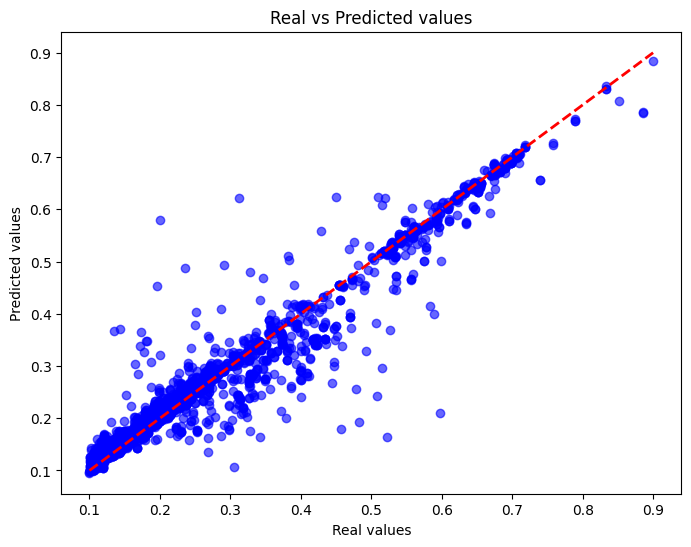

MSE: 0.001269
MAE: 0.018121
MAPE: 7.68449


In [21]:
get_prediction('Dataset2 XGBoost', model, X_test, y_test, y_train, metrics, show_prediction_vs_real=True)

In [23]:
nn_df2 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='tanh',
    validation_split=0.2
)

In [26]:
X_train = X_train.values
y_train = y_train.values.reshape(-1, 1)

In [27]:
nn_df2.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.009516 - Validation Error: 0.010414
Epoch 100/1000 - Training Error: 0.004059 - Validation Error: 0.004956
Epoch 200/1000 - Training Error: 0.003831 - Validation Error: 0.004752
Epoch 300/1000 - Training Error: 0.003699 - Validation Error: 0.004618
Epoch 400/1000 - Training Error: 0.003607 - Validation Error: 0.004553
Epoch 500/1000 - Training Error: 0.003496 - Validation Error: 0.004507
Epoch 600/1000 - Training Error: 0.003368 - Validation Error: 0.004420
Epoch 700/1000 - Training Error: 0.003419 - Validation Error: 0.004494
Epoch 800/1000 - Training Error: 0.003220 - Validation Error: 0.004347
Epoch 900/1000 - Training Error: 0.003274 - Validation Error: 0.004507


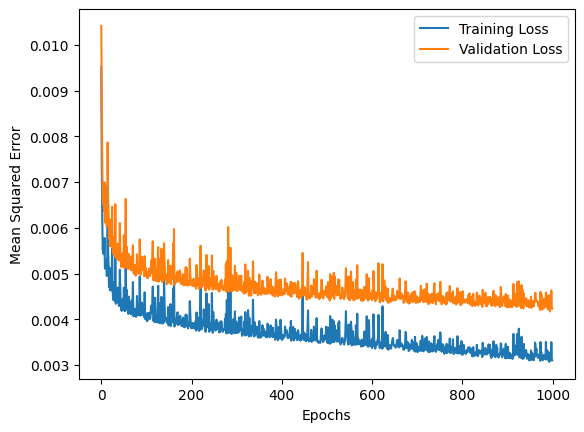

Predictions: [0.22432856 0.11026285 0.19929434 ... 0.2428885  0.19218168 0.19827708]


In [29]:
train_loss, val_loss = nn_df2.loss_epochs()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()
predictions_df2 = nn_df2.predict(X_test.values)
print("Predictions:", predictions_df2.flatten())

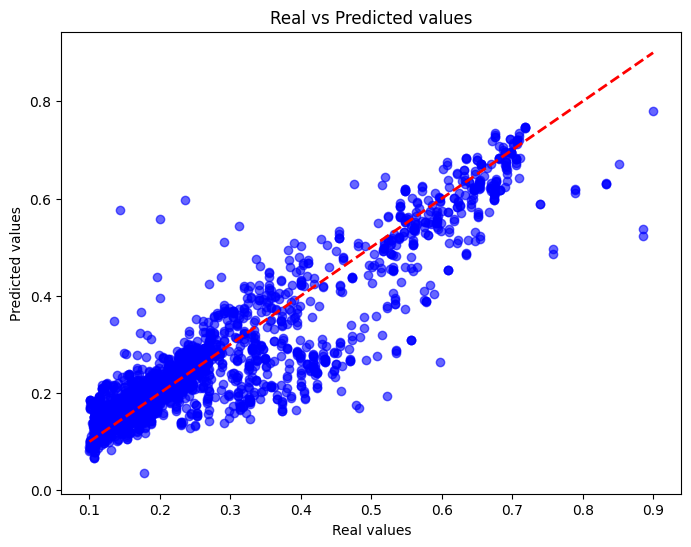

MSE: 0.003625
MAE: 0.038908
MAPE: 65.310331


In [30]:
get_prediction('NN from zero with tanh', nn_df2, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [35]:
nn_df2_2 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [36]:
nn_df2_2.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.006775 - Validation Error: 0.006404
Epoch 100/1000 - Training Error: 0.003725 - Validation Error: 0.003816
Epoch 200/1000 - Training Error: 0.003208 - Validation Error: 0.003477
Epoch 300/1000 - Training Error: 0.002630 - Validation Error: 0.002858
Epoch 400/1000 - Training Error: 0.002385 - Validation Error: 0.002695
Epoch 500/1000 - Training Error: 0.002092 - Validation Error: 0.002391
Epoch 600/1000 - Training Error: 0.002005 - Validation Error: 0.002440
Epoch 700/1000 - Training Error: 0.001812 - Validation Error: 0.002301
Epoch 800/1000 - Training Error: 0.001779 - Validation Error: 0.002305
Epoch 900/1000 - Training Error: 0.001767 - Validation Error: 0.002253


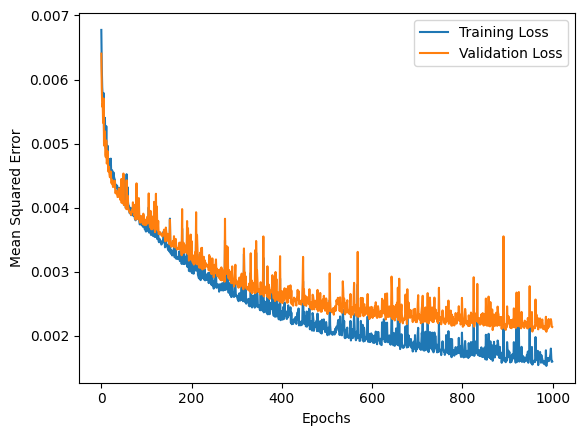

Predictions: [0.20352637 0.10863961 0.15940769 ... 0.2238673  0.19141863 0.17023198]


In [37]:
train_loss, val_loss = nn_df2_2.loss_epochs()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()
predictions_df2_2 = nn_df2_2.predict(X_test.values)
print("Predictions:", predictions_df2_2.flatten())

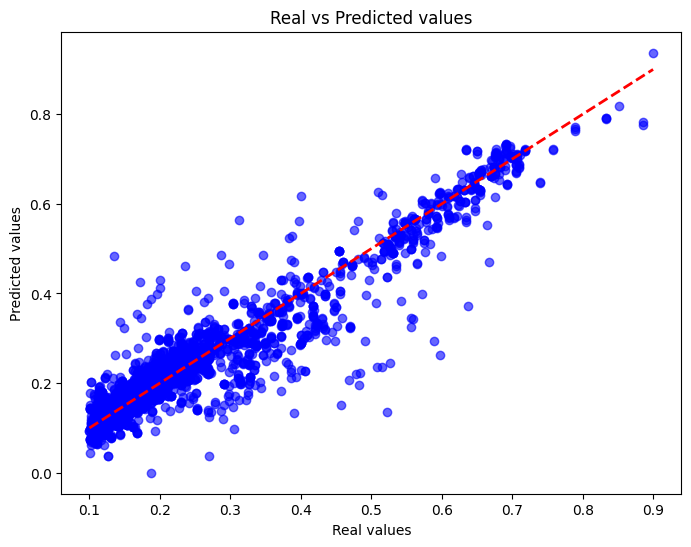

MSE: 0.00231
MAE: 0.030091
MAPE: 68.182598


In [38]:
get_prediction('NN from zero with relu', nn_df2_2, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [40]:
save_prediction_to_csv("model_results_dataset_2.csv", metrics)

## Part 3

Comparing predictions using the three models

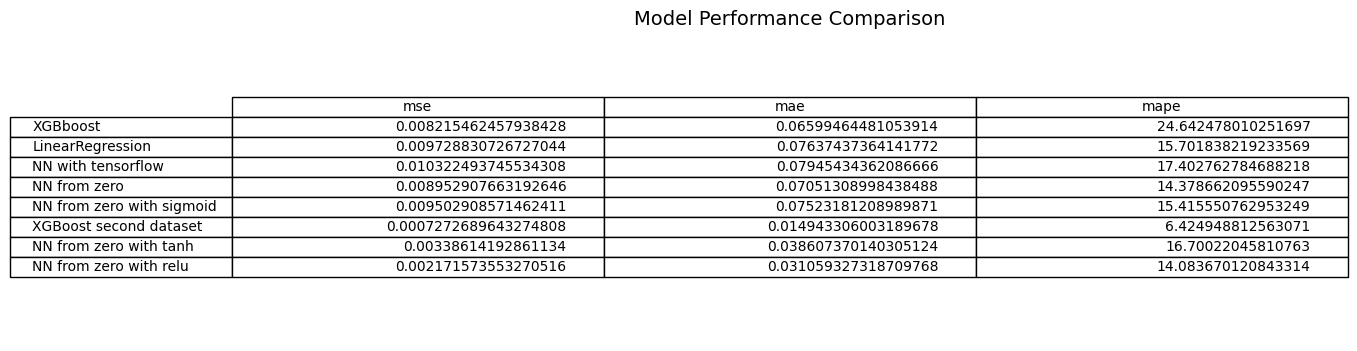

In [142]:
# Convert to DataFrame
model_prediction_df = pd.DataFrame(model_prediction).T  # Transpose so models = rows

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=model_prediction_df.values,
    colLabels=model_prediction_df.columns,
    rowLabels=model_prediction_df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

References

NN with tensor flow
https://www.datacamp.com/tutorial/one-hot-encoding-python-tutorial
https://www.tensorflow.org/guide/keras/sequential_model
https://numustafa.medium.com/deep-learning-neural-network-for-regression-with-tensorflow-f87968173520

Linear regression with NN
https://www.tensorflow.org/tutorials/keras/regression
https://pyimagesearch.com/2021/05/06/backpropagation-from-scratch-with-python/

https://mmuratarat.github.io/2020-01-09/backpropagation
https://udlbook.github.io/udlbook/


https://github.com/udlbook/udlbook/blob/main/Notebooks/Chap06/6_4_Momentum.ipynb
https://github.com/udlbook/udlbook/blob/main/Notebooks/Chap07/7_2_Backpropagation.ipynb
https://github.com/YanSte/DNN-Wine-Prediction/blob/main/dnn-wine-wine-quality-prediction-with-dnn.ipynb

https://anshulhep.medium.com/make-your-tensorflow-keras-predictions-faster-with-batch-size-8bbd780b9c08

https://www.quora.com/What-is-an-intuitive-explanation-of-momentum-in-training-neural-networks

Implementing cross validation
https://scikit-learn.org/stable/modules/cross_validation.html
https://medium.com/@avijit.bhattacharjee1996/implementing-k-fold-cross-validation-from-scratch-in-python-ae413b41c80d
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html
